# TICL Clustering algorithm

Here, we will try to accept a root data of a particular particle, then implement the following here, for a particular event:
1. For each layer, apply CLUE2D algorithm to cluster the hit points. These will be now called 'clusters' or vertices
2. Each cluster must have a few properties-
   (i)   x-centre
   (ii)  y-centre
   (iii) z-centre
   (iv)  total energy
   (v)   layer number
   (vi)
3. Now, multiple clusters are to be linked, forming what we call as 'Trackster'
4. A GNN will link tracksters belonging to the same particle


## Importing required packages

In [1]:
import numpy as np
import uproot
import awkward as ak
import matplotlib.pyplot as plt

In [2]:
pwd

'/Users/priyankar/Desktop/MSc_Project_HEP/TICL'

## Opening the root file

In [3]:
file=uproot.open("ntuple_pi+_100GeV_100keve.root:AllLayers")
#file.keys()
file.keys()
#branches=file.keys()[1:6]
branches=["hit_x","hit_y","hit_z","hit_l","hit_E"]
events=file.arrays(branches,library="ak")

In [4]:
events

<Array [{hit_x: [0, ...], ...}, ..., {...}] type='100000 * {hit_x: var * fl...'>

## Trying something- Extracting the data for each event

In [ ]:
event=events[10]

In [ ]:
event

In [ ]:
x=event.hit_x
y=event.hit_y
z=event.hit_z
l=event.hit_l
E=event.hit_E

In [ ]:
mask=l==17

In [ ]:
x[mask]

In [ ]:
layer=np.unique(l)
print(layer)
E_layer=[]
for i in layer:
    mask=(l==i)
    print(E[mask])
    E_layer.append(E[mask])

In [ ]:
E_layer=ak.Array(E_layer)

In [ ]:
E_layer

In [ ]:
# Using the argsort() and run_length()
order=ak.argsort(l)
l_sorted=l[order]
runs=ak.run_lengths(l_sorted)
x_sorted=x[order]
x_new=ak.unflatten(x_sorted,runs)

In [ ]:
x_new

## Attacking the data reformation

In [5]:
def build_layer_structure(event):
    #sort hits by layer
    order=ak.argsort(event.hit_l)
    l=event.hit_l[order]
    x=event.hit_x[order]
    y=event.hit_y[order]
    z=event.hit_l[order]
    E=event.hit_E[order]
    #number of hits per layer
    counts=ak.run_lengths(l)

    layers={
    "layer":ak.unflatten(l,counts),
    "x":ak.unflatten(x,counts),
    "y":ak.unflatten(y,counts),
    "z":ak.unflatten(z,counts),
    "E":ak.unflatten(E,counts)
    }
    return layers

In [6]:
#Testing the code
event=events[10]
data=build_layer_structure(event)
data["x"]

<Array [[0], [0], ..., [-2.91, ...], [-1.94, -3.88]] type='35 * var * float64'>

In [7]:
data["x"][6] # The hit_x values in layer 7

<Array [0, -0.97] type='2 * float64'>

In [8]:
len(data["x"][19])

44

## Implementing the CLUE2D

### Defining the parameters

In [9]:
dc=3.0
deltao=10
deltac=30
rhoc=0.001

In [10]:
dc=11.73

### Calculating local density

In [11]:
def compute_density(data,dc):
    rho_layers=[]
    for layer in range(len(data["x"])):
        x=ak.to_numpy(data["x"][layer])
        y=ak.to_numpy(data["y"][layer])
        E=ak.to_numpy(data["E"][layer])
        n=len(x)
        rho=np.zeros(n)
        for i in range(n):
            dx=x-x[i]
            dy=y-y[i]
            dist=np.sqrt(dx*dx+dy*dy)
            dist[i]=np.inf #Exclude self hit
            mask=dist<dc
            rho[i]=np.sum(E[mask])
        rho_layers.append(rho)
    return ak.Array(rho_layers)

In [12]:
#Testing
event=events[10]
data=build_layer_structure(event)
rho=compute_density(data,dc)
rho

<Array [[0], [0], ..., [...], [0.000106, 0.000193]] type='35 * var * float64'>

### Nearest Higher Density Neighbor

In [37]:
def nearest_higher(data,rho,deltao,deltac):
    dm=max(deltao,deltac)
    nh_all=[]
    delta_all=[]
    for layer in range(len(data["x"])):
        x=ak.to_numpy(data["x"][layer])
        y=ak.to_numpy(data["y"][layer])
        r=ak.to_numpy(rho[layer])

        n=len(x)
        delta=np.full(n,np.inf)
        nh=np.full(n,-1,dtype=int)

        for i in range(n):
            dx=x-x[i]
            dy=y-y[i]
            dist=np.sqrt(dx*dx+dy*dy)
            dist[i]=np.inf
            spatial_mask=dist<=dm
            if not np.any(spatial_mask):
                continue
            candidate_indices=np.where(spatial_mask)[0]
            valid_candidates=[]
            for j in candidate_indices:
                if (r[j]>r[i]) or ((r[j]==r[i]) and (j>i)):
                #if (r[j]>r[i]):
                    valid_candidates.append(j)
            if len(valid_candidates)==0:
                continue
            valid_candidates=np.array(valid_candidates)
            nearest_idx=valid_candidates[np.argmin(dist[valid_candidates])]
            delta[i]=dist[nearest_idx]
            nh[i]=nearest_idx
        nh_all.append(nh)
        delta_all.append(delta)

    return ak.Array(nh_all), ak.Array(delta_all)

In [38]:
#Testing
event=events[10]
data=build_layer_structure(event)
rho=compute_density(data,dc)
nh,delta=nearest_higher(data,rho,deltao,deltac)

In [39]:
nh

<Array [[-1], [-1], [-1], ..., [2, -1, 3, 1], [1, -1]] type='35 * var * int64'>

In [40]:
delta

<Array [[inf], [inf], ..., [17.7, ...], [9.27, inf]] type='35 * var * float64'>

### Seed/Outlier Classification

In [41]:
def classify_hits(rho,delta,rhoc,deltao,deltac):
    seeds=(rho>rhoc)&(delta>deltac)
    outliers=(rho<rhoc)&(delta>deltao)
    return seeds, outliers

### Building clusters

In [42]:
def build_clusters(data,seeds,outliers,nh):
    clusters=[]

    for layer in range(len(data["x"])):
        n_hits=len(data["x"][layer])
        clusterId=np.full(n_hits,-1)
        cluster_counter=0
        #----- Assign clusters -----#
        for i in range(n_hits):
            if seeds[layer][i]:
                clusterId[i]=cluster_counter
                cluster_counter+=1
       #---- Propagate clusters ----#
        for i in range(n_hits):
            if clusterId[i]!=-1:
                continue
            if outliers[layer][i]:
                continue
            parent=nh[layer][i]
            #Follow the NearestHigher chain
            path=[i]
            while parent!=-1 and parent<n_hits and clusterId[parent]==-1:
                path.append(parent)
                parent=nh[layer][parent]
            #Assign cluster if parent resolved
            if parent!=-1 and parent<n_hits and clusterId[parent]!=-1:
                cid=clusterId[parent]
                for p in path:
                    clusterId[p]=cid
        clusters.append(clusterId)
    return ak.Array(clusters)

### CLUE2D Pipeline

In [43]:
def run_clue2d(event,dc,rhoc,deltao,deltac):
    data=build_layer_structure(event)
    rho=compute_density(data,dc)
    nh,delta=nearest_higher(data,rho,deltao,deltac)
    seeds,outliers=classify_hits(rho,delta,rhoc,deltao,deltac)
    clusters=build_clusters(data,seeds,outliers,nh)
    return data,clusters,rho,delta,seeds,outliers

### Visualization of 2D clusters

In [44]:
def plot_layer_clusters(data,cluster,layer_id):
    x=ak.to_numpy(data["x"][layer_id])
    y=ak.to_numpy(data["y"][layer_id])
    c=ak.to_numpy(clusters[layer_id])
    plt.figure(figsize=(6,6))
    scatter=plt.scatter(x,y,c=c,cmap="tab20",s=40)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"CLUE2D Clusters - Layer {layer_id}")
    plt.colorbar(scatter,label="Cluster ID")
    plt.show()

In [45]:
def plot_layer_clusters(data, clusters, seeds, layer_id, save_path=None):
    x = ak.to_numpy(data["x"][layer_id])
    y = ak.to_numpy(data["y"][layer_id])
    c = ak.to_numpy(clusters[layer_id])
    s = ak.to_numpy(seeds[layer_id])
    
    plt.figure(figsize=(10, 8))
    
    # Plot noise (-1 cluster) first
    noise_mask = c == -1
    if np.any(noise_mask):
        plt.scatter(x[noise_mask], y[noise_mask],
                    c='gray', label='Noise (-1)', s=10, alpha=0.9)
    
    # Unique clusters excluding noise
    unique_clusters = np.unique(c)
    unique_clusters = unique_clusters[unique_clusters != -1]
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_clusters)))
    
    # Plot each cluster
    for idx, cluster_id in enumerate(sorted(unique_clusters)):
        cluster_mask = c == cluster_id
        plt.scatter(x[cluster_mask], y[cluster_mask],
                    label=f'Cluster {cluster_id}', s=15, color=colors[idx])
        
        # Optional: mark the seed of the cluster
        seed_mask = cluster_mask & s
        if np.any(seed_mask):
            plt.scatter(x[seed_mask], y[seed_mask],
                        c='black', marker='x', s=100, linewidth=2)
    
    plt.title(f'CLUE Clustering Results — Layer {layer_id}')
    plt.xlabel('x [mm]')
    plt.ylabel('y [mm]')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    
    if save_path:
        plt.savefig(save_path)
    plt.show()

### Testing the algorithm

In [46]:
#Plotting the actual hits
def plot_hits(data,layer_id):
    x = ak.to_numpy(data["x"][layer_id])
    y = ak.to_numpy(data["y"][layer_id])
    E = ak.to_numpy(data["E"][layer_id])
    plt.figure(figsize=(6,6))
    plt.scatter(x,y,s=20,c=E,cmap="viridis")
    plt.show()

In [47]:
event=events[0]
data,clusters,rho,delta,seeds,outliers=run_clue2d(event,dc,rhoc,deltao,deltac)

In [48]:
data["x"][28]

<Array [0, 0, 0, 0, 0, ..., -5.91, -4.97e-15, -2.91, 5.91] type='53 * float64'>

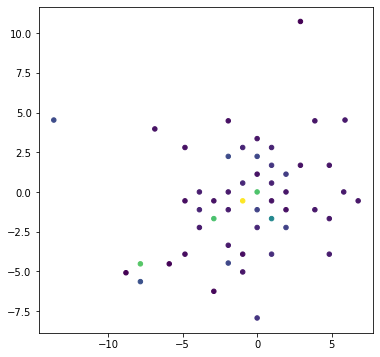

In [49]:
plot_hits(data,layer_id=28)

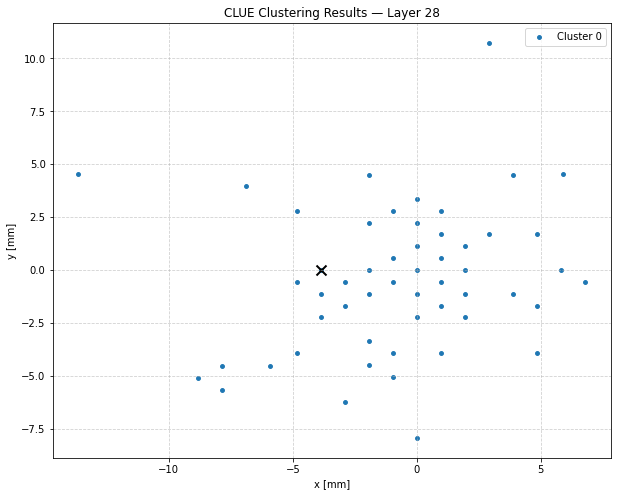

In [50]:
plot_layer_clusters(data,clusters,seeds,layer_id=28)

### Plotting the Decision graph

In [35]:
def plot_decision_graph(rho, delta, layer_id):

    r = ak.to_numpy(rho[layer_id])
    d = ak.to_numpy(delta[layer_id])

    plt.figure(figsize=(6,6))

    plt.scatter(r, d, s=20)

    plt.xlabel("rho")
    plt.ylabel("delta")

    plt.title(f"CLUE Decision Graph Layer {layer_id}")

    plt.show()

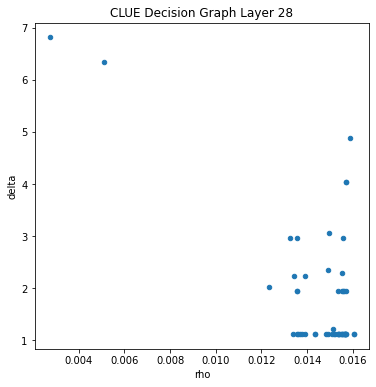

In [36]:
plot_decision_graph(rho, delta, layer_id=28)

## Debugging

In [ ]:
print(len(data["x"][19]))

In [ ]:
for i in range(len(data["x"])):
    print(i, len(data["x"][i]))

In [ ]:
print(rho[28])

In [ ]:
print(delta[28])

In [ ]:
layer_id=28
r = ak.to_numpy(rho[layer_id])
d = ak.to_numpy(delta[layer_id])

print(len(r), len(d))

In [ ]:
print(np.max(data["E"][layer_id]))

In [ ]:
layer = 28

x = ak.to_numpy(data["x"][layer])
y = ak.to_numpy(data["y"][layer])

dx = x[:,None] - x[None,:]
dy = y[:,None] - y[None,:]

dist = np.sqrt(dx**2 + dy**2)

print(dist)

In [ ]:
layer=28
x = ak.to_numpy(data["x"][layer])
y = ak.to_numpy(data["y"][layer])
dx = x[:, None] - x[None, :]
dy = y[:, None] - y[None, :]
dist = np.sqrt(dx**2 + dy**2)
mean_dist = np.mean(dist[dist>0])

In [ ]:
mean_dist

In [ ]:
1.2*9.773456914084623

In [ ]:
mean_distance=[]
for layer in range(35):
    x = ak.to_numpy(data["x"][layer])
    y = ak.to_numpy(data["y"][layer])
    dx = x[:, None] - x[None, :]
    dy = y[:, None] - y[None, :]
    dist = np.sqrt(dx**2 + dy**2)
    mean_dist = np.mean(dist[dist>0])
    mean_distance.append(mean_dist)

In [ ]:
mean_distance

In [ ]:
#dist

### Debugging-2

In [ ]:
for layer in range(len(data["x"])):
    r = ak.to_numpy(rho[layer])
    print(layer, "rho min:", np.min(r), "rho max:", np.max(r))

In [ ]:
for layer in range(len(data["x"])):
    d = ak.to_numpy(delta[layer])
    print(layer, "delta min:", np.min(d), "delta max:", np.max(d))

In [ ]:
rho_all = ak.to_numpy(ak.flatten(rho))
delta_all = ak.to_numpy(ak.flatten(delta))

rho_all = rho_all[np.isfinite(rho_all)]
delta_all = delta_all[np.isfinite(delta_all)]

In [ ]:
rhoc   = np.percentile(rho_all, 85)
deltac = np.percentile(delta_all, 90)
deltao = np.percentile(delta_all, 60)

In [ ]:
rhoc

In [ ]:
print("rho range:", rho_all.min(), rho_all.max())
print("delta range:", delta_all.min(), delta_all.max())